# Intro

This notebook displays docker disk usage in a Home Assistant OS installation.  It uses a Plotly Sunburst plot and ipyDataGrid to display the usage per image and per container, and the shared image layers and other docker disk usage.  It can be viewed from a standard Home Assistant dashboard using a WebPage Card and Voila:

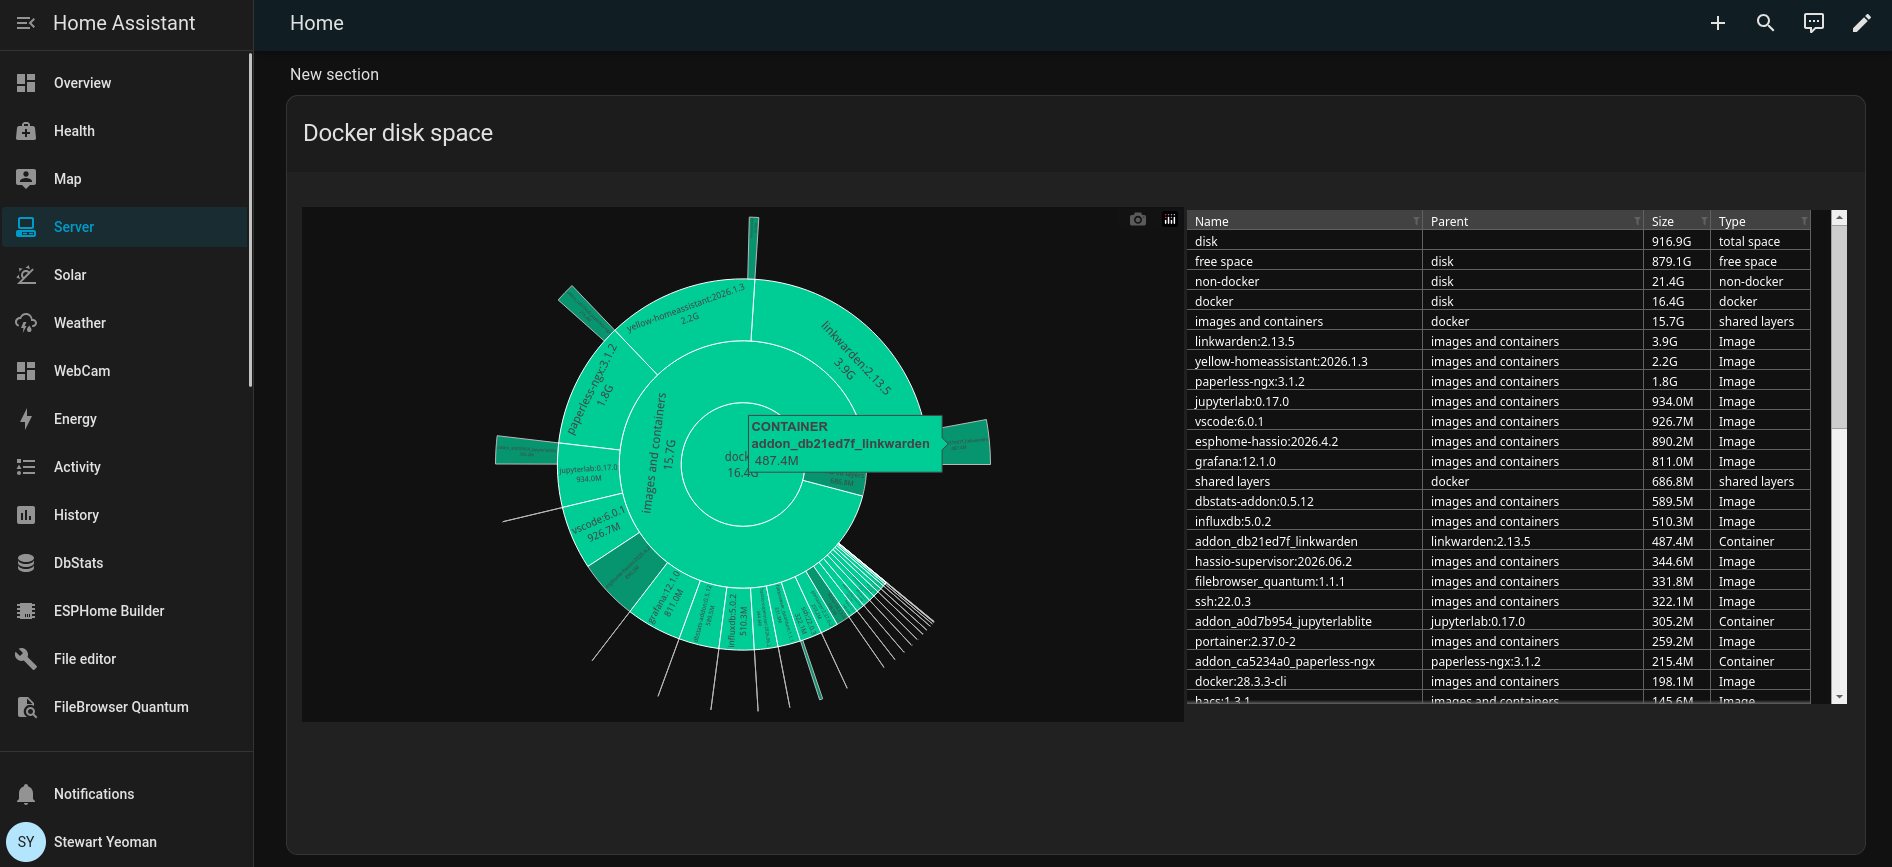



# Imports

## Display a splash screen before time-consuming imports start
The splash screen is needed because it takes about 15 seconds on my NVME drive to perform the "du" command on the Home Assistant bare metal host /var/lib/docker directory.  This happens way down below in the "Get total size" section.  At least the splash screen indicates that something lengthy is expected to be happening at this point in time.

The splash screen is a Stack widget, and once all the steps below complete, at the very end another set of widgets is created and added to this stack widget, and then those widgets are brought to the front, above the splash screen, so that they can be seen and interacted with.

Sadly, Voila cannot cache and re-use kernels, so every new viewing of this notebook will cause someone to suffer through the splash screen experience in order to view fresh up-to-date data (although for another project I have hacked together a version of Voila that does do exactly this kind of caching).

In [ ]:
import ipywidgets

In [ ]:
from IPython.display import display, HTML

In [ ]:
# https://github.com/plotly/plotly.py/issues/5208
# voila-skeleton-container
custom_css = """
<style>
.plot-container {
    width: 100%;
    height: 100%;
}
</style>
<style>
.voila-skeleton-container {
    height: 0 !important;
}
</style>
<style>
.voila-skeleton-post {
    height: 0 !important;
}
</style>
<style>
.voila-skeleton-avatar {
    height: 0 !important;
}
</style>
<style>
.voila-skeleton-line {
    height: 0 !important;
}
</style>
"""
display(HTML(custom_css))

In [ ]:
html_widget = ipywidgets.HTML(
    value='''
    <center><b>Please wait; collecting data...</b></center><br>
    <a href="https://commons.wikimedia.org/wiki/File:Electr%C3%B3n_Espiritual.gif" target="_blank" title="Click for image license" >
    <img src="https://upload.wikimedia.org/wikipedia/commons/3/3c/Electr%C3%B3n_Espiritual.gif" width="100%" height="400"></a>''',
    layout = { 'width': '100%', 
             #  'border': '3px solid cyan'
             }
)

html_widget.style.background = 'black'

In [ ]:
stack = ipywidgets.Stack([html_widget], selected_index=0, 
                         layout = { 'width': '100%', 'height': '515px',
                                  #  'border': '3px solid green' 
                                  })
stack

## Get the data using the docker and plumbum libraries

In [ ]:
import docker

In [ ]:
from plumbum import SshMachine

## Store the data first in namedtuples and next in Pandas dataframes

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from collections import namedtuple

## Format the data using the humanize library

In [ ]:
import humanize

## Display the data using the ipywidgets DataGrid and Plotly Figure Widget

In [ ]:
from ipydatagrid import Expr, DataGrid, TextRenderer

In [ ]:
monokai_datagrid_style = {
    "background_color": "#2c292d",
    "grid_line_color": "#a698eb7a",
    "header_background_color": "#2c292d9a",
    "header_grid_line_color": "#fc98675a",
    "selection_fill_color": "#78dce81a",
    "selection_border_color": "#ffd866",
    "header_selection_fill_color": "#ab9df24a",
    "header_selection_border_color": "lawngreen",
    "cursor_fill_color": "#78dce87a",
    "cursor_border_color": "#ff6188",
}

In [ ]:
import plotly.graph_objects as go

# Get Docker sizes
Connect to the internal address of the host, which on HAOS installations is always **172.30.32.1**

In [ ]:
client = docker.DockerClient(base_url='ssh://root@172.30.32.1:22222',
                            use_ssh_client=True)

In [ ]:
client_df_json = client.df()

Running: *str(client_df_json)[:400]* 

will return:

"{'LayersSize': 15837640596, 'Images': [{'Containers': 1, 'Created': 1781612840, 'Id': 'sha256:0f7914b9d19c583caebecdfc678c2875b3bd6006cdb126b76ea7bd7a7d2c5e21', 
'Labels': {'io.hass.arch': 'aarch64', 'io.hass.base.arch': 'aarch64', 'io.hass.base.image': 'ghcr.io/home-assistant/base:3.22', 'io.hass.base.name': 'python', 
           'io.hass.base.version': '2026.05.0', 'io.hass.type': 'supervisor', 'io.hass.vers"

## Extract Image sizes

In [ ]:
df_images = pd.DataFrame(client_df_json['Images'])

In [ ]:
len(df_images)

### The images dataframe should look like this:
*using print(df_images.tail(2).to_markdown())*

|    |   Containers |    Created | Id                                                                      | Labels                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | ParentId   | RepoDigests                                                                                                          | RepoTags                                           |   SharedSize |      Size |
|---:|-------------:|-----------:|:------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------|:---------------------------------------------------------------------------------------------------------------------|:---------------------------------------------------|-------------:|----------:|
| 23 |            1 | 1711370356 | sha256:cf983293e22b9cd32a2ddcb34657538f38ac9d653f3a0209e4cd9be141fd3c50 | {'io.hass.arch': 'aarch64', 'io.hass.base.image': 'hassioaddons/base', 'io.hass.base.name': 'alpine', 'io.hass.base.version': '15.0.7', 'io.hass.description': 'A cross-platform system monitoring tool', 'io.hass.name': 'Glances', 'io.hass.type': 'addon', 'io.hass.version': '0.21.1', 'maintainer': 'Franck Nijhof <frenck@addons.community>', 'org.opencontainers.image.authors': 'Franck Nijhof <frenck@addons.community>', 'org.opencontainers.image.created': '2024-03-25T22:19:07Z', 'org.opencontainers.image.description': 'A cross-platform system monitoring tool', 'org.opencontainers.image.documentation': 'https://github.com/hassio-addons/addon-glances/blob/main/README.md', 'org.opencontainers.image.licenses': 'MIT', 'org.opencontainers.image.revision': '831ceff48c8d5eb67879a418604091319757cd88', 'org.opencontainers.image.source': 'https://github.com/hassio-addons/addon-glances', 'org.opencontainers.image.title': 'Glances', 'org.opencontainers.image.url': 'https://addons.community', 'org.opencontainers.image.vendor': 'Home Assistant Community Add-ons', 'org.opencontainers.image.version': '0.21.1'} |            | ['ghcr.io/hassio-addons/glances/aarch64@sha256:facc9ae4e9d2fa462591ab36e87242ff08da60b4f1024eae1c5e6550903db317']    | ['ghcr.io/hassio-addons/glances/aarch64:0.21.1']   |            0 | 116786981 |
| 24 |            1 | 1707565390 | sha256:06b103b344956e6aba53772497609b3c684bfd4b919fee58196da1dab5a81ad6 | {'io.hass.arch': 'aarch64', 'io.hass.base.arch': 'aarch64', 'io.hass.base.image': 'arm64v8/alpine:3.19', 'io.hass.base.name': 'alpine', 'io.hass.base.version': '2023.12.2', 'io.hass.description': 'Simple browser-based file editor for Home Assistant', 'io.hass.name': 'File editor', 'io.hass.type': 'addon', 'io.hass.url': 'https://github.com/home-assistant/addons/tree/master/configurator', 'io.hass.version': '5.8.0', 'org.opencontainers.image.created': '2024-02-10 11:42:33+00:00', 'org.opencontainers.image.source': 'https://github.com/home-assistant/docker-base', 'org.opencontainers.image.version': '5.8.0'}                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |            | ['homeassistant/aarch64-addon-configurator@sha256:e14b4dc75501be8dd0e50e459ef32f8e67be0d9c3a2cfc544fa6c805d4580914'] | ['homeassistant/aarch64-addon-configurator:5.8.0'] |            0 | 131125053 |

Running: 

*df_images.dtypes*

will return:

<pre>
Containers      int64
Created         int64
Id             object
Labels         object
ParentId       object
RepoDigests    object
RepoTags       object
SharedSize      int64
Size            int64
dtype:         object</pre>

### Clean the data

#### Convert numeric columns to float 
This is to work around a DataGrid bug which fails to display bigint properly

In [ ]:
df_images['SharedSize'] = df_images['SharedSize'].astype(np.float64)

In [ ]:
df_images['Size'] = df_images['Size'].astype(np.float64)

#### Remove nan values

In [ ]:
df_images.fillna(0.0, inplace=True)

## Extract Container sizes

In [ ]:
df_containers = pd.DataFrame(client_df_json['Containers'])

### The containers dataframe should look like this:
using print(df_containers.tail(2).to_markdown())

|    | Id                                                               | Names                   | Image                                | ImageID                                                                 | Command              |    Created | Ports   |   SizeRw |   SizeRootFs | Labels                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | State   | Status                  | HostConfig                | NetworkSettings                                                                                                                                                                                                                                                                                                                                                                    | Mounts                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|---:|:-----------------------------------------------------------------|:------------------------|:-------------------------------------|:------------------------------------------------------------------------|:---------------------|-----------:|:--------|---------:|-------------:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------|:------------------------|:--------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 22 | 90aa933abc4f1356207d51f4ce44b931bfd3b1285b17c21948a69c1d40dc903b | ['/addon_cb646a50_get'] | ghcr.io/hacs/aarch64-addon-get:1.3.1 | sha256:686b126214ea591f402b839782b9484c2d18c41498a75d7fcdf43abd6cfc2bf9 | /init /etc/addon/run | 1768858094 | []      |    18270 |    152673104 | {'io.hass.arch': 'aarch64', 'io.hass.base.arch': 'aarch64', 'io.hass.base.image': 'ghcr.io/home-assistant/aarch64-base:3.20', 'io.hass.base.name': 'python', 'io.hass.base.version': '2024.08.0', 'io.hass.description': 'The easiest way to get HACS for Home Assistant', 'io.hass.name': 'Get HACS', 'io.hass.type': 'addon', 'io.hass.url': 'https://github.com/hacs/addons/tree/main/get', 'io.hass.version': '1.3.1', 'org.opencontainers.image.created': '2024-09-04 11:00:22+00:00', 'org.opencontainers.image.source': 'https://github.com/home-assistant/docker-base', 'org.opencontainers.image.version': '1.3.1', 'supervisor_managed': ''} | exited  | Exited (0) 5 months ago | {'NetworkMode': 'bridge'} | {'Networks': {'hassio': {'IPAMConfig': None, 'Links': None, 'Aliases': None, 'MacAddress': '', 'DriverOpts': None, 'GwPriority': 0, 'NetworkID': 'e47e922d9e10aa635efbe2b1657b9ddc642fab66b22b2703b1f885e449f7bc49', 'EndpointID': '', 'Gateway': '', 'IPAddress': '', 'IPPrefixLen': 0, 'IPv6Gateway': '', 'GlobalIPv6Address': '', 'GlobalIPv6PrefixLen': 0, 'DNSNames': None}}} | [{'Type': 'bind', 'Source': '/mnt/data/supervisor/addons/data/cb646a50_get', 'Destination': '/data', 'Mode': '', 'RW': True, 'Propagation': 'rprivate'}, {'Type': 'bind', 'Source': '/dev', 'Destination': '/dev', 'Mode': '', 'RW': False, 'Propagation': 'rprivate'}, {'Type': 'bind', 'Source': '/mnt/data/supervisor/homeassistant', 'Destination': '/homeassistant', 'Mode': '', 'RW': True, 'Propagation': 'rprivate'}, {'Type': 'bind', 'Source': '/mnt/data/supervisor/cid_files/addon_cb646a50_get.cid', 'Destination': '/run/cid', 'Mode': '', 'RW': False, 'Propagation': 'rprivate'}] |

### Clean the data

#### Convert numeric columns to float 
This is to work around a DataGrid bug which fails to display bigint properly

In [ ]:
df_containers['SizeRw'] = df_containers['SizeRw'].astype(np.float64)

In [ ]:
df_containers['SizeRootFs'] = df_containers['SizeRootFs'].astype(np.float64)

#### Remove nan values

In [ ]:
df_containers.fillna(0.0, inplace=True)

## Note on container sizes:
For each container, its Image Size plus its Container SizeRw = Container SizeRootFs EXACTLY.

# Iterate through all elements

We will retain some existing columns, and calculate some new columns for each row of these two dataframes.  

The set of new columns will define a new row, which will be stored in a named tuple called **New_Row**.  

All such new_rows will be stored in a list, which will be converted to a DataFrame at the end.

We will perform a join to the list of images for each container.

We will also sum certain values as we go.

In [ ]:
New_Row = namedtuple(typename = 'New_Row', 
                     field_names = ['Name', 'Parent', 'Size', 'Type'],
                     defaults = [None, None, None, None ]
                    )

So to display this:

- the image slices need to use their non-shared size (Image Size - Image SharedSize).

- The containers need to use their SizeRw.

- The sum of all the Image SharedSize needs to be displayed as row named "docker-shared-image", on the same level as the images.

There should be an inner level with a parent called "docker", which has a size of 0 and should be the parent of images 
The total docker disk usage is the sum of:
- docker-shared-image
- image slice sizes
- container SizeRw

The total disk usage needs to have the total docker disk usage subtracted from it. This value will be the non-docker disk usage.
It should be at the same level as the docker disk usage.
Also at that level should be the free space.

## New rows for the Images

In [ ]:
total_shared_size = 0
total_docker_size = 0
total_unique_image_size = 0
total_container_size = 0

image_id_to_image_name = {}

new_rows = []

for a_tuple in df_images.itertuples():

    # --------------------------------------------------------
    # Every tuple in this loop will correspond to an Image
    new_row_Type = 'Image'

    # --------------------------------------------------------
    # Every tuple in this loop will have docker as the parent
    new_row_Parent = 'images and containers'

    # --------------------------------------------------------
    # Calculate the size
    size = a_tuple.Size
    shared_size = a_tuple.SharedSize
    unique_size = size - shared_size

    new_row_Size = unique_size

    # Add to the running size totals
    total_shared_size += shared_size
    total_unique_image_size += unique_size
    total_docker_size += shared_size + unique_size

    # --------------------------------------------------------
    # Calculate the name
    repo_path = a_tuple.RepoTags[0]
    image_id = a_tuple.Id

    # Default the image name to the image_id
    repo_name = image_id

    if repo_path is not None:
        repo_path = repo_path.replace('-aarch64', '').replace('aarch64-', '').replace('aarch64', '').replace("/:", ":")
        repo_path_segments = repo_path.split('/')
        repo_path_segments.reverse()
    
        # Keep looping through the path segments until we find a good one
        for repo_path_segment in repo_path_segments:
            candidate = repo_path_segment
            if ':' in candidate:
                part_a, part_b = candidate.split(':')
            else:
                part_a = candidate 
                
            if part_a != '' and part_a != 'addon-get':
                repo_name = candidate
                break
    
            if part_a == 'addon-get':
                repo_name = repo_path_segments[1] + ':' + part_b
                break
        
    image_id_to_image_name[image_id] = repo_name

    new_row = New_Row(Name = repo_name, Parent = new_row_Parent, Size = new_row_Size, Type = new_row_Type)

    new_rows.append(new_row)


new_row = New_Row(Name = 'shared layers', Parent = 'docker', Size = total_shared_size, Type = 'shared layers')
new_rows.append(new_row)

## New rows for the Containers

In [ ]:
for a_tuple in df_containers.itertuples():

    container_unique_size = a_tuple.SizeRw
    total_container_size += container_unique_size
    total_docker_size += container_unique_size

    new_row_Type = 'Container'
    new_row_Size = container_unique_size
    
    parent_id = a_tuple.ImageID
    new_row_Parent = image_id_to_image_name[parent_id] 
    new_row_Name = a_tuple.Names[0].replace('/', '')

    new_row = New_Row(Name = new_row_Name, Parent = new_row_Parent, Size = new_row_Size, Type = new_row_Type)

    new_rows.append(new_row)

In [ ]:
new_row = New_Row(Name = 'images and containers', Parent = 'docker', Size = total_container_size + total_unique_image_size, Type = 'shared layers')
new_rows.append(new_row)

# Get total size

In [ ]:
host_mach = SshMachine("172.30.32.1", port=22222)

In [ ]:
du_lines = host_mach["du"]["-sbx"]["/var/lib/docker/"]().split('\n')

In [ ]:
real_docker_bytes, docker_path = du_lines[0].split()

In [ ]:
real_docker_bytes = float(real_docker_bytes)

In [ ]:
df_lines = host_mach["df"]["-B1"]["/var/lib/docker"]().split('\n')

In [ ]:
device, disk_total, disk_used, disk_free, pct, mount_point = df_lines[1].split()

In [ ]:
disk_total = float(disk_total)
disk_free = float(disk_free)
disk_used = float(disk_used)

disk_free = disk_total - disk_used

In [ ]:
non_docker = disk_used - real_docker_bytes 

In [ ]:
hidden_docker_disk_usage = real_docker_bytes - total_docker_size

In [ ]:
new_row = New_Row(Name = 'docker', Parent = 'disk', Size = total_docker_size, Type = 'docker')
new_rows.append(new_row)

In [ ]:
new_row = New_Row(Name = 'non-docker', Parent = 'disk', Size = disk_used - total_docker_size, Type = 'non-docker')
new_rows.append(new_row)

In [ ]:
new_row = New_Row(Name = 'free space', Parent = 'disk', Size = disk_free, Type = 'free space')
new_rows.append(new_row)

In [ ]:
new_row = New_Row(Name = 'disk', Parent = '', Size = disk_total, Type = 'total space')
new_rows.append(new_row)

# Create final DataFrame

In [ ]:
df = pd.DataFrame(new_rows, columns=New_Row._fields)

# Helper functions

## def gnu_size_string()

In [ ]:
def gnu_size_string(a_numeric_filesize):
    return humanize.filesize.naturalsize(a_numeric_filesize, gnu=True)

## def graph_callback()

In [ ]:
# https://plotly.com/python/click-events/
# This function is not really used, but it COULD be used
# to highlight the selected row in the DatGrid
def graph_callback(trace, points, selector):
    print(trace['labels'][points.point_inds[0]])

# The graph

In [ ]:
formatted_values = df.Size.apply(gnu_size_string)

In [ ]:
custom_data = []
for type_value in df['Type']:
    if type_value == 'Image':
        custom_data.append('<b>IMAGE</b><br>')
    elif type_value == 'Container':
        custom_data.append('<b>CONTAINER</b><br>')
    else:
        custom_data.append('')

In [ ]:
# https://stackoverflow.com/a/58190352 to see how to set line color
fig =go.FigureWidget(go.Sunburst(
    name = "",
    labels=df.Name,
    parents=df.Parent,
    values=df.Size,
    text = formatted_values,
    hovertemplate='%{customdata}<b>%{label} </b> <br> %{text}',
    customdata = custom_data,
    branchvalues="total", marker = dict(line=dict(color="#ffffff"))
    )
)
# Update layout for tight margin
# See https://plotly.com/python/creating-and-updating-figures/
fig = fig.update_layout(margin = dict(t=10, l=0, r=0, b=10), template = "plotly_dark")
trace = fig.data[0]

# This
trace.on_click(graph_callback)
fig = fig.add_class("plot-container")

# The grid
We want the size column to display with the strings generated by the humanize module, but we want the sorting by size to be numeric.  The way to do this is to create a custom Renderer for the size column that pulls humanized values from Somewhere Else.

ipyDataGrid allows you to have tuple columns, and the Renderer function can be defined so that it pulls values from any of the positions in the tuple.  However, if you attempt this with the Size column by having the first position in the tuple to be the actual numeric size, and the second position in the tuple to be the humanized string value, then you will find that ipyDataGrid has converted the whole tuple to a string, and it applies string sorting to the size, which is incorrect.

What you need to do is to find some OTHER string column (like Parent) which you can replace with 2-tuples, with the first position being the original value of that column (i.e. Parent), and the second position being the humanized size.  Then you need TWO Renderers: one for the now mutated Parent column, which pulls out the first position in each tuple for display as the Parent, and another renderer for the Size column, which pulls out the second position in each tuple of the Parent column to render as the Size value.

Using this method, the Parent column sorts correctly, because the combined tuple/string has the Parent value first.  The Size column still sorts correctly, since its value is purely numeric, and so ipyDataGrid preserves this when it sends the column to JavaScript, allowing the sorting to be purely numeric.  But the Render of the Size column will show the humanized string value which is stashed in the hijacked Parent column's second tuple position.

In [ ]:
# This temp_list is needed to convert empty strings into single spaces.
# Without this, the parent displays the humanized size for rows where the
# parent is blank.
temp_list = [ x if x != '' else ' ' for x in df['Parent'] ]

# The following converts the parent column into a comma separated 2-tuple
df['Parent'] = list(zip(temp_list, df.Size.apply(gnu_size_string)))

In [ ]:
def display_formatted_value(cell):
    return cell.metadata.data['Parent'][1]

In [ ]:
value_renderer = TextRenderer(
    text_value=Expr(display_formatted_value)
)


In [ ]:
def display_column_one(cell):
    return cell.value[0]

In [ ]:
column_one_renderer = TextRenderer(
    text_value=Expr(display_column_one)
)

In [ ]:
df.set_index('Name', inplace=True)

In [ ]:
df.sort_values('Size', ascending=False, inplace=True)

In [ ]:
index_renderer = TextRenderer(
    horizontal_alignment="left",
)

In [ ]:
grid = DataGrid(df, renderers = {'Parent':column_one_renderer, 'Size':value_renderer, 'Name': index_renderer},
               #layout = { 'width': '660px', 'border': '3px solid red' },
               layout = { 'width': '1170px', 
                          #'border': '3px solid red' 
                        },
               flex_basis = 'auto',
               column_widths = {'Name': 236, 'Parent': 221, 'Size': 67, 'Type': 100})

# The layout widget

In [ ]:
the_hbox = ipywidgets.HBox([fig, grid], layout = ipywidgets.Layout(width = '100%', 
                                                                   #border = '3px solid yellow', 
                                                                   justify_content='flex-end',
                                                                   align_items='stretch',
                                                                   align_content='stretch'
                                                                  )
                          )

In [ ]:
stack.children = stack.children + (the_hbox,)

In [ ]:
stack.selected_index=1